In [2]:
import zipfile
import os

zip_path = "/content/archive.zip"
dataset = "."

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dataset)

print(f"'{zip_path}' extracted to '{dataset}'")
print("Contents of the current directory:")
print(os.listdir(dataset))

'/content/archive.zip' extracted to '.'
Contents of the current directory:
['.config', 'archive.zip', 'Testing', 'Training', 'sample_data']


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)
Epoch 1/12 | Train Loss: 0.7368 | Train Acc: 70.28% | Val Loss: 0.4033 | Val Acc: 84.43% | LR: 0.000500 | Time: 2

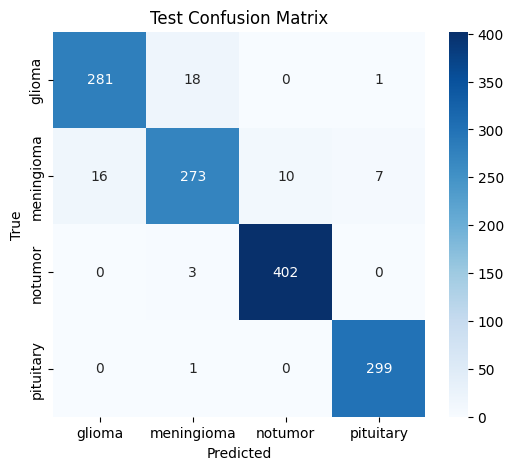

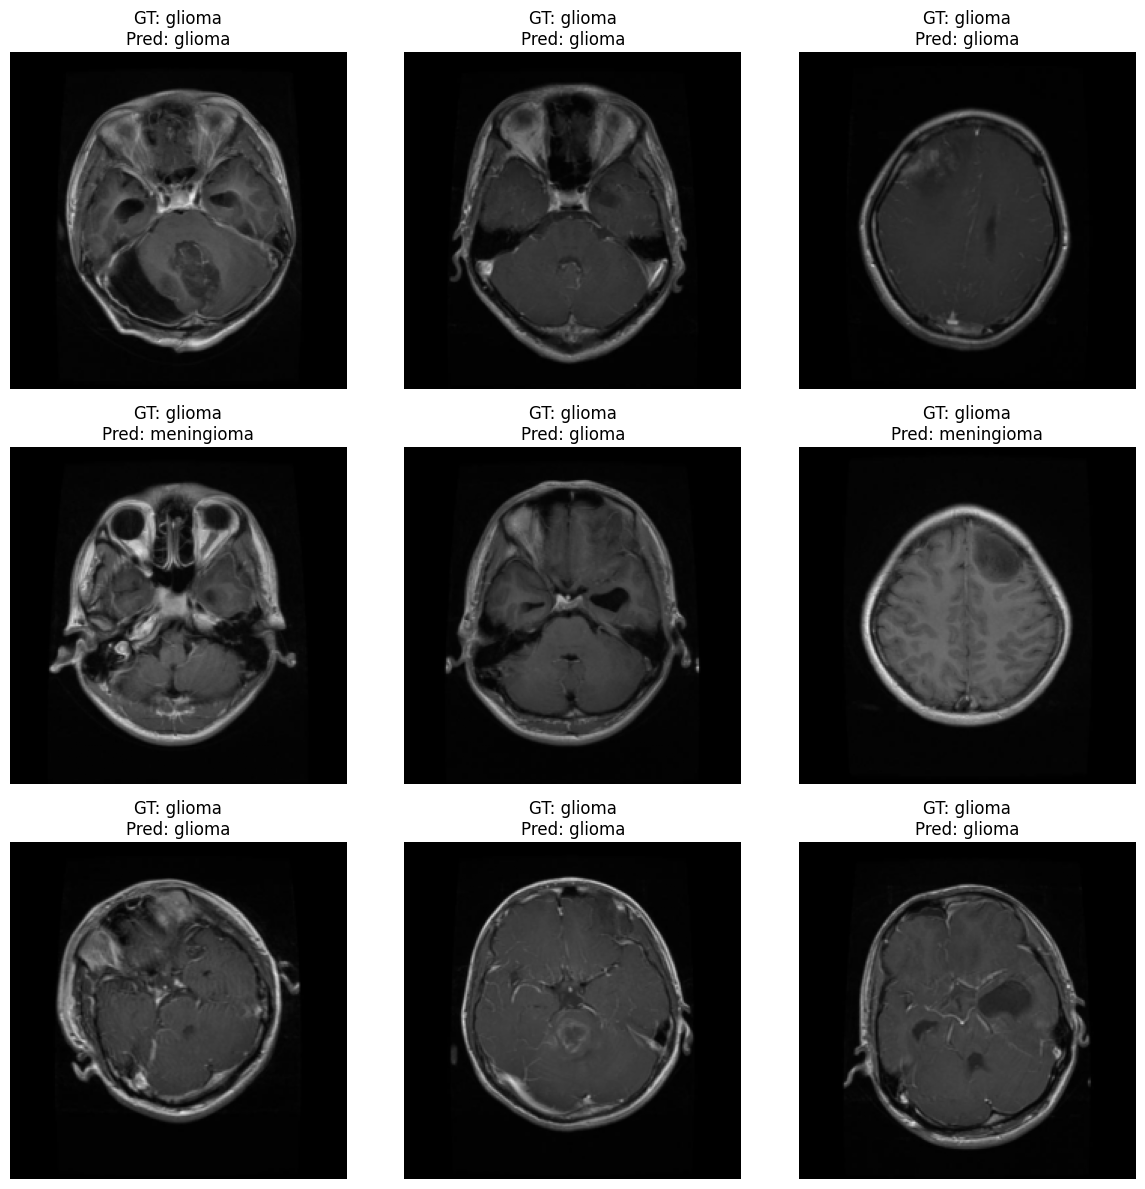

All done. To view TensorBoard in Colab run:
%load_ext tensorboard
%tensorboard --logdir runs


In [5]:
# Colab-ready: Brain Tumor Classification + TensorBoard + Scheduler + Report
# Paste into a Colab cell and run.

# --- Install sklearn in case it's missing (Colab usually has it) ---
!pip install -q scikit-learn

# --- Imports ---
import os, random, time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, utils

from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


# USER: set your dataset root here (contains Training/ and Testing/)

DATA_ROOT = "/content"  # <-- change if needed
train_dir = os.path.join(DATA_ROOT, "Training")
test_dir  = os.path.join(DATA_ROOT, "Testing")

# Hyperparams

IMG_SIZE = (224, 224)
BATCH = 32
NUM_EPOCHS = 12
LR = 5e-4
SEED = 42
LOG_DIR = "runs/exp1"

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Transforms & Datasets

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

full_train = datasets.ImageFolder(train_dir, transform=train_transform)
class_names = full_train.classes
print("Classes:", class_names)

# split train/val (80/20)
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])
# ensure val uses test_transform (no augmentation)
val_ds.dataset.transform = test_transform

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2)

test_ds = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=2)


# Simple CNN (same shape expectations)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 112x112
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 56x56
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 28x28
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

model = SimpleCNN(num_classes=len(class_names)).to(device)
print(model)

# Loss / Opt / Scheduler / Writer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # halven every 5 epochs
writer = SummaryWriter(LOG_DIR)

# add model graph to tensorboard (pass a dummy input)
try:
    dummy = torch.zeros((1, 3, IMG_SIZE[0], IMG_SIZE[1]), device=device)
    writer.add_graph(model, dummy)
except Exception as e:
    print("Warning: could not add graph:", e)

# Utility: visualize a batch to TensorBoard

def log_images(loader, tag, epoch):
    imgs, labels = next(iter(loader))
    img_grid = utils.make_grid(imgs[:16], nrow=4, normalize=True, scale_each=True)
    writer.add_image(tag, img_grid, epoch)

# Training + Validation function
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    loss_sum = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    if len(all_preds) == 0:
        return 0.0, np.array([]), np.array([])
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = loss_sum / len(loader.dataset)
    acc = (all_preds == all_labels).mean() * 100.0
    return avg_loss, all_preds, all_labels, acc

def train_loop(model, train_loader, val_loader, epochs):
    global_step = 0
    best_val_acc = 0.0
    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        t0 = time.time()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # log per-batch if desired (comment to reduce logs)
            # writer.add_scalar("train/batch_loss", loss.item(), global_step)
            global_step += 1

        train_loss = epoch_loss / len(train_loader.dataset)
        train_acc = correct / total * 100.0

        # Validation
        val_loss, val_preds, val_labels, val_acc = evaluate(model, val_loader)
        scheduler.step()  # step scheduler per epoch

        # TensorBoard scalars
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Acc/train", train_acc, epoch)
        writer.add_scalar("Acc/val", val_acc, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

        # Log some images and predictions for this epoch
        log_images(val_loader, "val/images", epoch)

        # Confusion matrix on validation (log as figure)
        try:
            cf = confusion_matrix(val_labels, val_preds, labels=list(range(len(class_names))))
            fig, ax = plt.subplots(figsize=(6,5))
            sns.heatmap(cf, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues", ax=ax)
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            ax.set_title(f"Val Confusion Matrix (epoch {epoch})")
            writer.add_figure("Val/confusion_matrix", fig, epoch)
            plt.close(fig)
        except Exception as e:
            print("Confusion matrix logging failed:", e)

        t1 = time.time()
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f} | Time: {t1-t0:.1f}s")

        # Save best model by val_acc
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_brain_tumor_model.pth")
            print("  -> Saved best model (val_acc improved).")

    writer.flush()
    print("Training finished. Best Val Acc: %.2f%%" % best_val_acc)

# Run training
train_loop(model, train_loader, val_loader, NUM_EPOCHS)

# Load best model and evaluate on test set

best_model = SimpleCNN(num_classes=len(class_names)).to(device)
best_model.load_state_dict(torch.load("best_brain_tumor_model.pth", map_location=device))
best_model.eval()

# Evaluate on testloader and produce classification report
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = best_model(imgs)
        preds = out.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

acc = (all_preds == all_labels).mean() * 100.0
print(f"\nTest Accuracy: {acc:.2f}%\n")

# Classification report
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)

# Confusion matrix plot (and log to TB)
cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test Confusion Matrix")
plt.show()
writer.add_figure("Test/confusion_matrix", fig)
plt.close(fig)


# Visualize some test predictions

def show_predictions(model, loader, n=9):
    model.eval()
    imgs, labels = next(iter(loader))
    plt.figure(figsize=(12,12))
    for i in range(n):
        img = imgs[i]
        label = labels[i].item()
        with torch.no_grad():
            out = model(img.unsqueeze(0).to(device))
            pred = out.argmax(1).item()
        img_np = img.permute(1,2,0).numpy()
        plt.subplot(3,3,i+1)
        plt.imshow(img_np)
        plt.title(f"GT: {class_names[label]}\nPred: {class_names[pred]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(best_model, test_loader, n=9)

# Close writer
writer.close()

print("All done. To view TensorBoard in Colab run:\n%load_ext tensorboard\n%tensorboard --logdir runs")


# The Robust Approach with all three models cnn, mobilenet, efficientnet at 30 epochs and see which performs best and keep the " Loss / Optimizer / Scheduler / AMP / Writer " same for each

Device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAUL


Starting training for: simple_cnn

[simple_cnn] Epoch 1/30 | Train Loss: 0.7691 | Train Acc: 71.28% | Val Loss: 0.3827 | Val Acc: 85.04% | LR: 0.000500 | Time: 30.0s
  -> simple_cnn: saved best model (val_acc 85.04%)
[simple_cnn] Epoch 2/30 | Train Loss: 0.3391 | Train Acc: 87.96% | Val Loss: 0.2722 | Val Acc: 88.45% | LR: 0.000500 | Time: 28.6s
  -> simple_cnn: saved best model (val_acc 88.45%)
[simple_cnn] Epoch 3/30 | Train Loss: 0.2247 | Train Acc: 91.81% | Val Loss: 0.2819 | Val Acc: 88.28% | LR: 0.000500 | Time: 31.9s
[simple_cnn] Epoch 4/30 | Train Loss: 0.1431 | Train Acc: 94.59% | Val Loss: 0.1509 | Val Acc: 95.10% | LR: 0.000500 | Time: 28.7s
  -> simple_cnn: saved best model (val_acc 95.10%)
[simple_cnn] Epoch 5/30 | Train Loss: 0.0750 | Train Acc: 97.64% | Val Loss: 0.2537 | Val Acc: 91.86% | LR: 0.000500 | Time: 29.3s
[simple_cnn] Epoch 6/30 | Train Loss: 0.0762 | Train Acc: 97.59% | Val Loss: 0.1975 | Val Acc: 93.79% | LR: 0.000500 | Time: 28.4s
[simple_cnn] Epoch 7/30 |

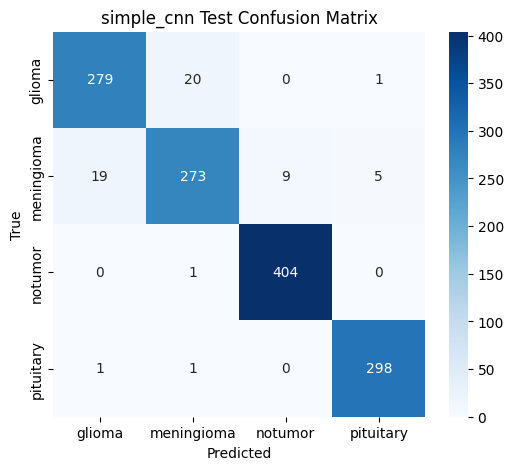

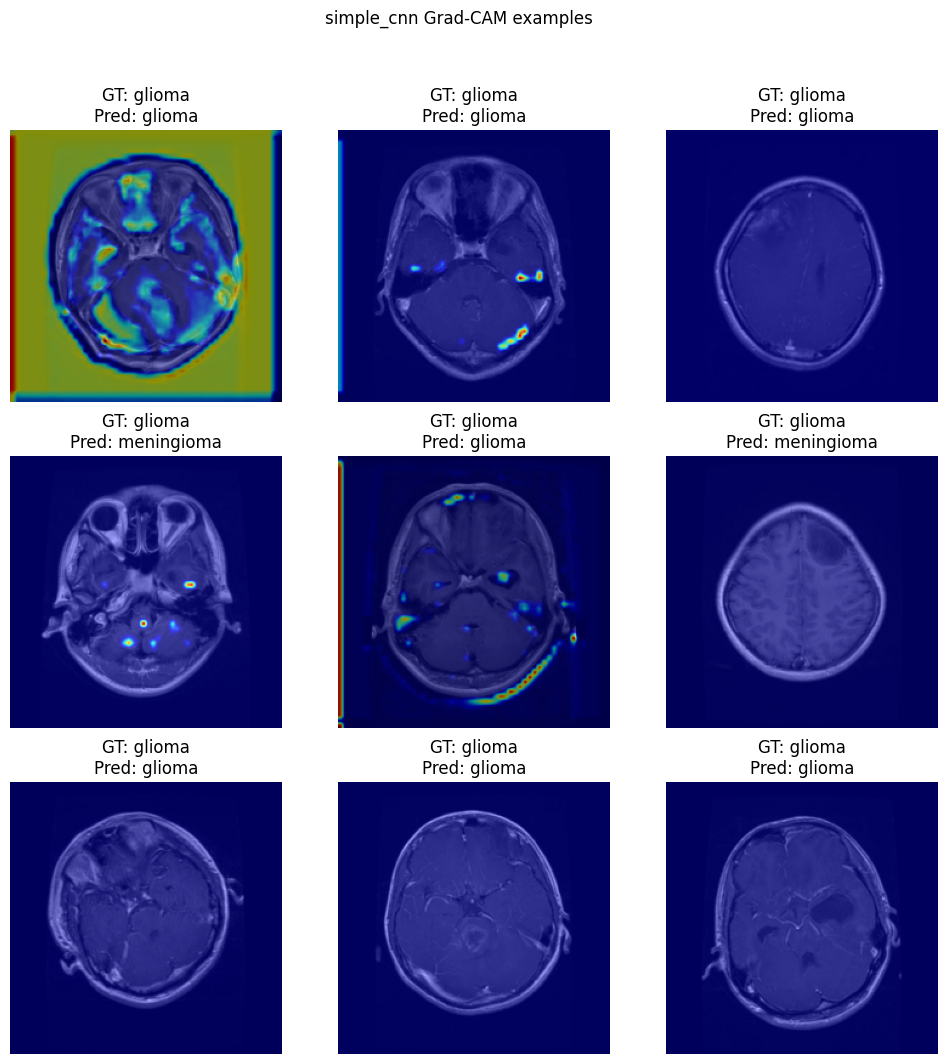


Starting training for: mobilenetv3_small

[mobilenetv3_small] Epoch 1/30 | Train Loss: 0.3845 | Train Acc: 86.41% | Val Loss: 0.6462 | Val Acc: 77.87% | LR: 0.000500 | Time: 46.7s
  -> mobilenetv3_small: saved best model (val_acc 77.87%)
[mobilenetv3_small] Epoch 2/30 | Train Loss: 0.1302 | Train Acc: 95.38% | Val Loss: 0.3354 | Val Acc: 89.33% | LR: 0.000500 | Time: 29.8s
  -> mobilenetv3_small: saved best model (val_acc 89.33%)
[mobilenetv3_small] Epoch 3/30 | Train Loss: 0.0692 | Train Acc: 97.86% | Val Loss: 0.1720 | Val Acc: 93.09% | LR: 0.000500 | Time: 30.0s
  -> mobilenetv3_small: saved best model (val_acc 93.09%)
[mobilenetv3_small] Epoch 4/30 | Train Loss: 0.0547 | Train Acc: 98.23% | Val Loss: 0.5043 | Val Acc: 87.31% | LR: 0.000500 | Time: 31.1s
[mobilenetv3_small] Epoch 5/30 | Train Loss: 0.0447 | Train Acc: 98.29% | Val Loss: 0.2294 | Val Acc: 92.48% | LR: 0.000500 | Time: 29.6s
[mobilenetv3_small] Epoch 6/30 | Train Loss: 0.0485 | Train Acc: 98.58% | Val Loss: 0.1224 | 

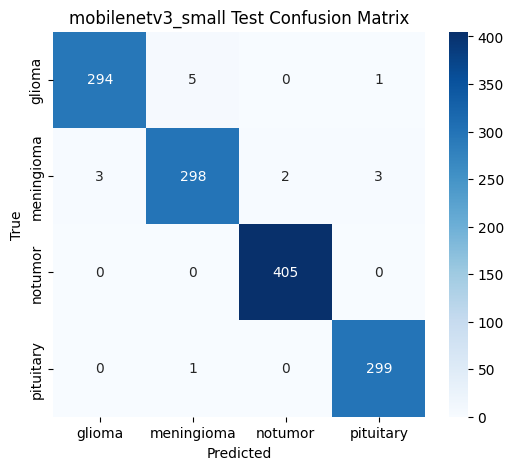

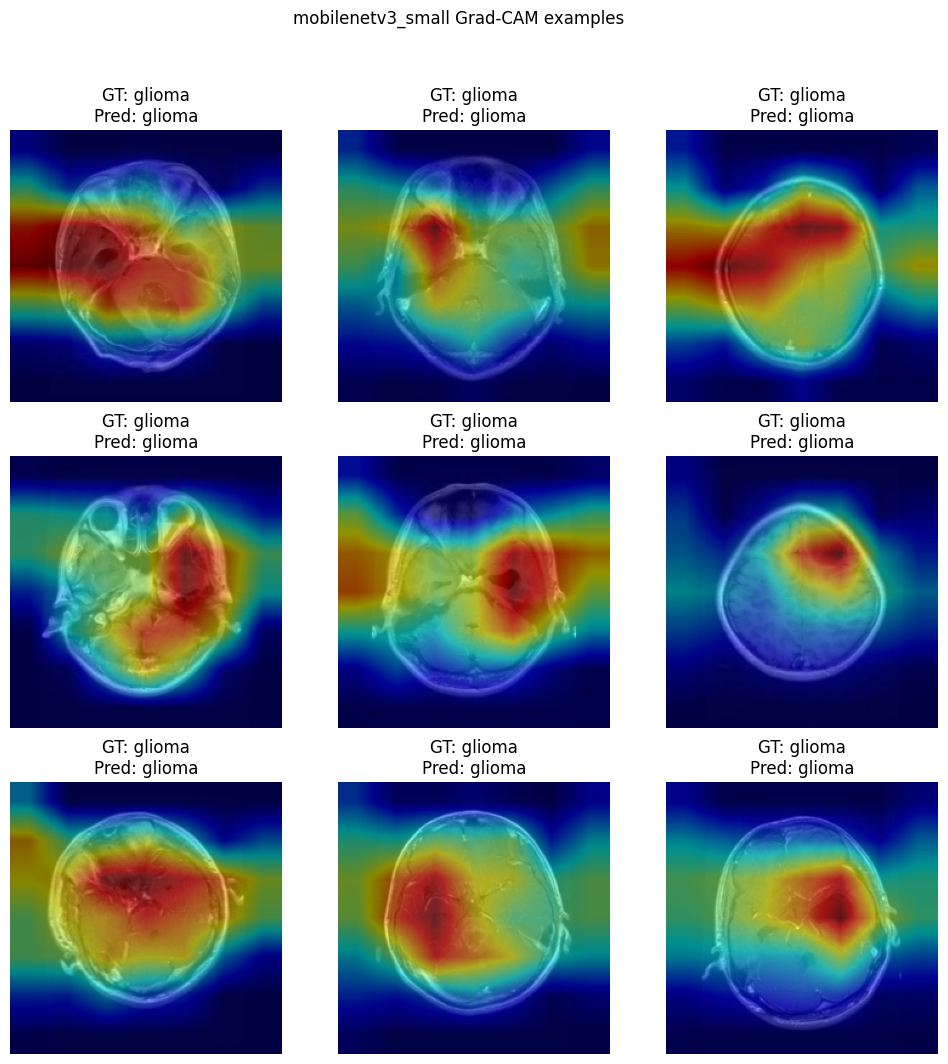


Starting training for: efficientnet_b0

[efficientnet_b0] Epoch 1/30 | Train Loss: 0.2895 | Train Acc: 90.11% | Val Loss: 0.0798 | Val Acc: 97.11% | LR: 0.000500 | Time: 57.0s
  -> efficientnet_b0: saved best model (val_acc 97.11%)
[efficientnet_b0] Epoch 2/30 | Train Loss: 0.0858 | Train Acc: 97.00% | Val Loss: 0.1185 | Val Acc: 96.41% | LR: 0.000500 | Time: 33.1s
[efficientnet_b0] Epoch 3/30 | Train Loss: 0.0633 | Train Acc: 98.01% | Val Loss: 0.0712 | Val Acc: 97.73% | LR: 0.000500 | Time: 34.3s
  -> efficientnet_b0: saved best model (val_acc 97.73%)
[efficientnet_b0] Epoch 4/30 | Train Loss: 0.0397 | Train Acc: 98.75% | Val Loss: 0.0912 | Val Acc: 97.99% | LR: 0.000500 | Time: 32.8s
  -> efficientnet_b0: saved best model (val_acc 97.99%)
[efficientnet_b0] Epoch 5/30 | Train Loss: 0.0279 | Train Acc: 99.08% | Val Loss: 0.0555 | Val Acc: 98.16% | LR: 0.000500 | Time: 34.1s
  -> efficientnet_b0: saved best model (val_acc 98.16%)
[efficientnet_b0] Epoch 6/30 | Train Loss: 0.0360 | Tra

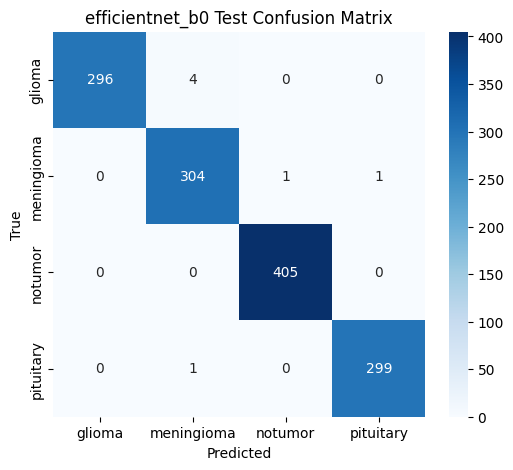

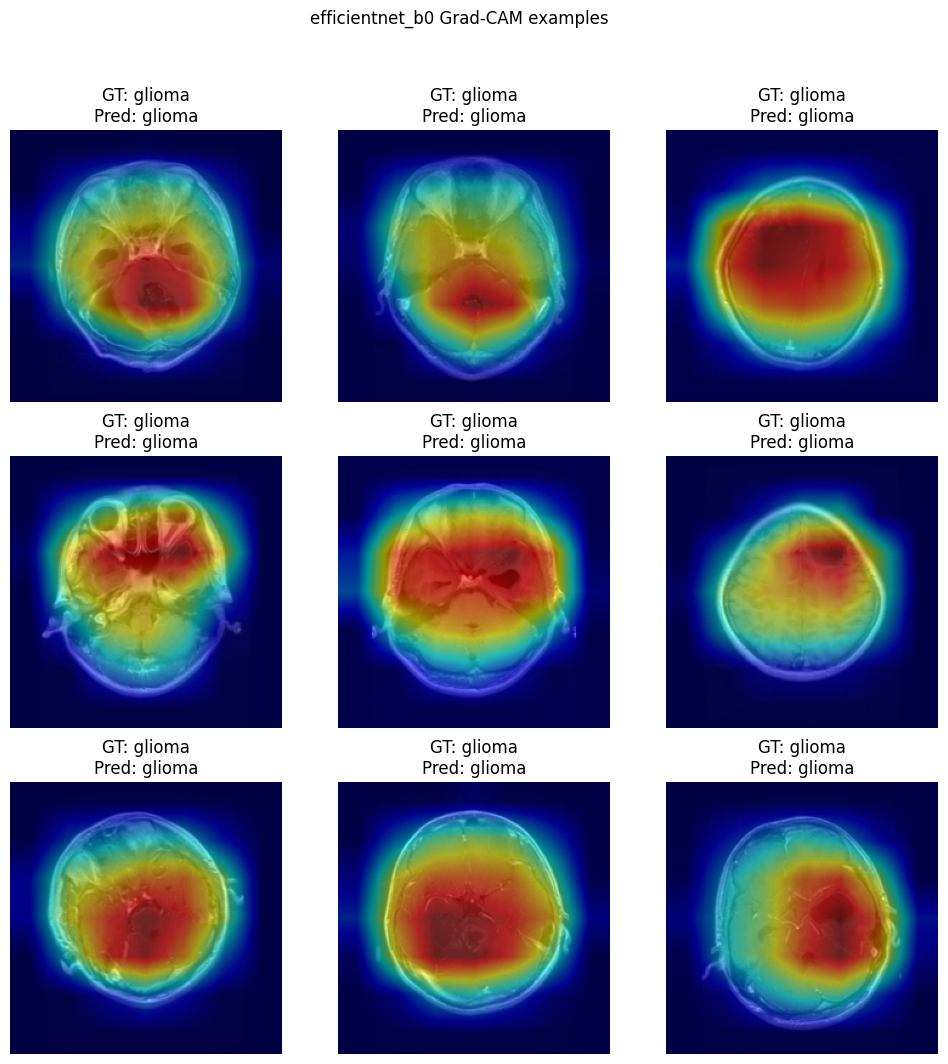

All models finished.
Run TensorBoard with:
%load_ext tensorboard
%tensorboard --logdir runs


In [9]:
# Full pipeline: train 3 models (SimpleCNN, MobileNetV3-Small, EfficientNet-B0)
# Mixed precision, StepLR, TensorBoard, Classification report, Confusion matrix, Grad-CAM
# Requires: pytorch, torchvision, scikit-learn, seaborn, pytorch-grad-cam

!pip install -q scikit-learn seaborn grad-cam

import os, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch, torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, utils, models
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# pytorch-grad-cam imports
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# USER: set your dataset root here (contains Training/ and Testing/)

DATA_ROOT = "/content"  # change if needed
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

# Hyperparams (same for each model)
IMG_SIZE = (224, 224)
BATCH = 32
NUM_EPOCHS = 30    # as requested
LR = 5e-4          # same optimizer LR for all models
SEED = 42
STEP_SIZE = 8
GAMMA = 0.1        # StepLR gamma
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Repro
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Transforms & Datasets
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
class_names = full_train.classes
num_classes = len(class_names)
print("Classes:", class_names)

# split train/val 80/20
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])
# make sure val uses test transform
val_ds.dataset.transform = test_transform

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Utilities
def unnormalize(tensor):
    """Unnormalize tensor image (C,H,W) with ImageNet stats to numpy HWC 0..1"""
    mean = np.array([0.485,0.456,0.406])
    std  = np.array([0.229,0.224,0.225])
    img = tensor.cpu().permute(1,2,0).numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    return img

def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    return fig

def find_last_conv_layer(model):
    """Return the last nn.Conv2d module in the model (module object)"""
    last_conv = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            last_conv = m
    if last_conv is None:
        raise RuntimeError("No Conv2d layer found in model")
    return last_conv

# Model factories
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 112
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 56
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 28
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

def create_mobilenetv3(num_classes):
    model = models.mobilenet_v3_small(pretrained=True)  # smaller variant
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model

def create_efficientnet_b0(num_classes):
    model = models.efficientnet_b0(pretrained=True)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

# Shared training config helper
def make_optimizer_scheduler(model, lr=LR):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
    return optimizer, scheduler

# Single training function reused for each model
from torch.amp import GradScaler, autocast # Updated import for GradScaler and autocast

def train_one_model(model, name, num_epochs=NUM_EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer, scheduler = make_optimizer_scheduler(model, lr=LR)
    scaler = GradScaler() # Removed 'cuda' argument if it was present, default is often good
    log_dir = f"runs/{name}"
    writer = SummaryWriter(log_dir)

    # add model graph (try)
    try:
        dummy = torch.zeros((1,3,IMG_SIZE[0],IMG_SIZE[1]), device=DEVICE)
        writer.add_graph(model, dummy)
    except Exception:
        pass

    best_val_acc = 0.0
    best_path = f"best_{name}.pth"

    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        t0 = time.time()

        for imgs, labels in train_loader:
            imgs = imgs.to(DEVICE); labels = labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type=='cuda')):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total * 100.0

        # Validation evaluate
        val_loss, val_preds, val_labels, val_acc = evaluate_model(model, val_loader, criterion)
        scheduler.step()

        # logging
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Acc/train", train_acc, epoch)
        writer.add_scalar("Acc/val", val_acc, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

        # log some validation images (unnormalized)
        try:
            imgs_v, labels_v = next(iter(val_loader))
            imgs_v_vis = torch.stack([unnormalize_for_tb(x) for x in imgs_v[:16]])
            grid = utils.make_grid(imgs_v_vis, nrow=4)
            writer.add_image("val/images", grid, epoch)
        except Exception:
            pass

        # confusion matrix to TB
        try:
            cm = confusion_matrix(val_labels, val_preds, labels=list(range(num_classes)))
            fig = plot_confusion_matrix(cm, class_names, title=f"Val Confusion Matrix (epoch {epoch})")
            writer.add_figure("Val/confusion_matrix", fig, epoch)
            plt.close(fig)
        except Exception:
            pass

        t1 = time.time()
        print(f"[{name}] Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f} | Time: {t1-t0:.1f}s")

        # save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f"  -> {name}: saved best model (val_acc {best_val_acc:.2f}%)")

    writer.flush()
    writer.close()

    # After training evaluate on test set, produce report + confusion matrix + gradcam figures
    # load best weights
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    test_report_and_gradcam(model, name, best_path)

# Helper to unnormalize tensor for TensorBoard display
def unnormalize_for_tb(tensor):
    mean = torch.tensor([0.485,0.456,0.406], device=tensor.device).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=tensor.device).view(3,1,1)
    img = tensor * std + mean
    return img.cpu()

# Evaluate helper used in train loop
def evaluate_model(model, loader, criterion):
    model.eval()
    all_preds, all_labels = [], []
    loss_sum = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE); labels = labels.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            all_preds.append(preds.cpu().numpy()); all_labels.append(labels.cpu().numpy())
    if len(all_preds) == 0:
        return 0.0, np.array([]), np.array([]), 0.0
    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    avg_loss = loss_sum / len(loader.dataset)
    acc = (all_preds == all_labels).mean() * 100.0
    return avg_loss, all_preds, all_labels, acc

# Test-time reporting + Grad-CAM visualization
def test_report_and_gradcam(model, name, model_path, n_gradcam=9):
    model = model.to(DEVICE)
    model.eval()
    # Test predictions
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            preds = out.argmax(1).cpu().numpy()
            all_preds.append(preds); all_labels.append(labels.numpy())
    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    acc = (all_preds == all_labels).mean() * 100.0
    print(f"\n[{name}] Test Accuracy: {acc:.2f}%\n")
    print(f"[{name}] Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # Confusion matrix + plot
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    fig = plot_confusion_matrix(cm, class_names, title=f"{name} Test Confusion Matrix")
    plt.show()

    # Grad-CAM on some test images
    # prepare GradCAM using last conv layer
    target_layer = find_last_conv_layer(model)
    cam = GradCAM(model=model, target_layers=[target_layer]) # Removed 'device' argument

    imgs, labels = next(iter(test_loader))
    imgs = imgs[:n_gradcam]
    labels = labels[:n_gradcam]
    imgs_device = imgs.to(DEVICE)

    plt.figure(figsize=(12,12))
    for i in range(len(imgs)):
        input_tensor = imgs_device[i].unsqueeze(0)
        # compute cam for predicted class
        out = model(input_tensor)
        pred = out.argmax(1).item()
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]  # (H,W) numpy
        # overlay on unnormalized image
        img_np = unnormalize(imgs[i]).astype(np.float32)
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        plt.subplot(3,3,i+1)
        plt.imshow(visualization)
        plt.title(f"GT: {class_names[labels[i]]}\nPred: {class_names[pred]}")
        plt.axis('off')
    plt.suptitle(f"{name} Grad-CAM examples")
    plt.show()

    # cleanup
    del cam

# Train all three models sequentially
models_to_run = [
    ("simple_cnn", SimpleCNN(num_classes=num_classes)),
    ("mobilenetv3_small", create_mobilenetv3(num_classes=num_classes)),
    ("efficientnet_b0", create_efficientnet_b0(num_classes=num_classes)),
]

for name, model in models_to_run:
    print("\n" + "="*60)
    print(f"Starting training for: {name}")
    print("="*60 + "\n")
    train_one_model(model, name, num_epochs=NUM_EPOCHS)

print("All models finished.")
print("Run TensorBoard with:\n%load_ext tensorboard\n%tensorboard --logdir runs")

# Brain Tumor Classification Models: Comparative Analysis

This document summarizes the performance of three different Convolutional Neural Network (CNN) models trained for brain tumor classification into four categories: `glioma`, `meningioma`, `notumor`, and `pituitary`.

## Models Evaluated

1.  **SimpleCNN**: A custom-built lightweight CNN architecture.
2.  **MobileNetV3-Small**: A pre-trained MobileNetV3-Small model fine-tuned for the task.
3.  **EfficientNet-B0**: A pre-trained EfficientNet-B0 model fine-tuned for the task.

All models were trained for 30 epochs with consistent hyperparameters (learning rate, batch size, etc.) and mixed-precision training for efficiency.

## Summary of Test Accuracies

After training and evaluation on a dedicated test set, the models achieved the following accuracies:

*   **SimpleCNN**: **95.65%**
*   **MobileNetV3-Small**: **98.86%**
*   **EfficientNet-B0**: **99.47%**

**EfficientNet-B0** demonstrated the highest performance among the three evaluated models on the given dataset.

## Evaluation Metrics and Visualizations

For each model, the following evaluation artifacts were generated:

*   **Epoch-wise Training Progress**: Logs showing training and validation loss/accuracy across all epochs, as well as the learning rate schedule. These can be explored in detail using TensorBoard.

*   **Classification Report**: Provides detailed performance metrics for each class, including:
    *   **Precision**: The proportion of correctly identified positive cases among all cases predicted as positive.
    *   **Recall**: The proportion of correctly identified positive cases among all actual positive cases.
    *   **F1-Score**: The harmonic mean of precision and recall, offering a balance between the two.
    *   **Support**: The number of actual occurrences of each class in the test set.

*   **Confusion Matrix**: A tabular visualization that allows for the performance of an algorithm to be seen visually. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

    ### SimpleCNN Confusion Matrix
    ![SimpleCNN Confusion Matrix](path/to/simple_cnn_confusion_matrix.png)

    ### MobileNetV3-Small Confusion Matrix
    ![MobileNetV3-Small Confusion Matrix](path/to/mobilenetv3_small_confusion_matrix.png)

    ### EfficientNet-B0 Confusion Matrix
    ![EfficientNet-B0 Confusion Matrix](path/to/efficientnet_b0_confusion_matrix.png)

*   **Grad-CAM Visualizations**: Gradient-weighted Class Activation Mapping (Grad-CAM) images highlight the regions of an input image that were most important for the model's classification decision. These are crucial for understanding model interpretability and ensuring that the model is focusing on relevant features.

    ### SimpleCNN Grad-CAM Examples
    ![SimpleCNN Grad-CAM](path/to/simple_cnn_grad_cam.png)

    ### MobileNetV3-Small Grad-CAM Examples
    ![MobileNetV3-Small Grad-CAM](path/to/mobilenetv3_small_grad_cam.png)

    ### EfficientNet-B0 Grad-CAM Examples
    ![EfficientNet-B0 Grad-CAM](path/to/efficientnet_b0_grad_cam.png)

**Note**: Replace `path/to/your_image.png` with the actual file paths where you save your generated images.